# TabICL vs TabPFN vs CatBoost

Focused three-way comparison on the small tabular benchmark.
- **TabICL** — tabular foundation model (in-context learning, zero HP tuning beyond ensemble size and softmax temperature)
- **TabPFN** — earlier foundation model (10-class cap, slower than TabICL on the same data)
- **CatBoost** — tuned via Optuna (50 trials per outer fold), strongest gradient booster on this benchmark

In [1]:
import joblib
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(context='poster')

In [2]:
ckpt, _ = joblib.load('results/optuna_models_ckpt.joblib')
db = pd.read_json('database.json').T
db['nrow'] = np.minimum(10000, db['nrow'])

MODELS = {
    'tabicl':   'TabICL',
    'tabpfn':   'TabPFN',
    'catboost': 'CatBoost',
}
FOLD_COLS  = ['prauc_fold_1', 'prauc_fold_2', 'prauc_fold_3', 'prauc_fold_4']
SPLIT_COLS = ['prauc_split_1', 'prauc_split_2', 'prauc_split_3', 'prauc_split_4']

rows = []
for ds, v in ckpt.items():
    for key, label in MODELS.items():
        if key in v:
            scores = v[key]['scores']
            if not any(np.isnan(s) for s in scores):
                rows.append({'dataset': ds, 'model': label,
                              **dict(zip(FOLD_COLS, scores)),
                              'time': v[key]['time']})
df = pd.DataFrame(rows)
df.columns = ['dataset', 'model'] + SPLIT_COLS + ['time']
df['mean_prauc'] = df[SPLIT_COLS].mean(axis=1)
for col in db.columns:
    df[col] = df['dataset'].map(db[col]).to_numpy()

# Only keep datasets where all 3 models have valid scores (head-to-head)
counts = df.groupby('dataset')['model'].nunique()
shared = counts[counts == len(MODELS)].index
df = df[df['dataset'].isin(shared)].reset_index(drop=True)
print(f'Shared datasets (all 3 models valid): {len(shared)}')

# Drop trivially-easy datasets where the worst model still > 0.99
df = df.groupby('dataset').filter(lambda x: x['mean_prauc'].min() < 0.99).reset_index(drop=True)
active = set(df['dataset'])
print(f'After dropping trivially-easy: {len(active)}')

Shared datasets (all 3 models valid): 127
After dropping trivially-easy: 107


In [3]:
summary = df.groupby('model').agg(
    n=('dataset', 'count'),
    mean_prauc=('mean_prauc', 'mean'),
    median_prauc=('mean_prauc', 'median'),
    median_time_s=('time', 'median'),
    mean_time_s=('time', 'mean'),
    total_time_h=('time', lambda x: x.sum() / 3600),
).round(4).sort_values('mean_prauc', ascending=False)
print(summary.to_string())

            n  mean_prauc  median_prauc  median_time_s  mean_time_s  total_time_h
model                                                                            
TabICL    107      0.8388        0.9250       190.2014     697.5415       20.7325
CatBoost  107      0.8058        0.9168       142.7374     622.6910       18.5078
TabPFN    107      0.7892        0.8899       723.7543    5297.5038      157.4536


## Pairwise win counts

How often each model beats each other on the same dataset (mean PR-AUC across 4 folds).

In [4]:
pivot = df.pivot_table(index='dataset', columns='model', values='mean_prauc')
labels = list(MODELS.values())

win = pd.DataFrame(index=labels, columns=labels, dtype=object)
for a in labels:
    for b in labels:
        if a == b:
            win.loc[a, b] = '—'
        else:
            wins = (pivot[a] > pivot[b]).sum()
            total = pivot[[a, b]].dropna().shape[0]
            win.loc[a, b] = f'{wins}/{total} ({wins/total*100:.0f}%)'
print('Wins (row beats column):')
print(win.to_string())
print()
for a in labels:
    for b in labels:
        if a >= b:
            continue
        sub = pivot[[a, b]].dropna()
        delta = sub[a] - sub[b]
        print(f'{a} − {b}:  mean Δ = {delta.mean():+.4f}  median Δ = {delta.median():+.4f}  '
              f'(margin ≥0.01: {a} wins {(delta>=0.01).sum()}, {b} wins {(delta<=-0.01).sum()}, ties {((-0.01<delta)&(delta<0.01)).sum()})')

Wins (row beats column):
                TabICL        TabPFN      CatBoost
TabICL               —  77/107 (72%)  81/107 (76%)
TabPFN    30/107 (28%)             —  52/107 (49%)
CatBoost  24/107 (22%)  55/107 (51%)             —

TabICL − TabPFN:  mean Δ = +0.0496  median Δ = +0.0031  (margin ≥0.01: TabICL wins 45, TabPFN wins 5, ties 57)
CatBoost − TabICL:  mean Δ = -0.0330  median Δ = -0.0091  (margin ≥0.01: CatBoost wins 12, TabICL wins 51, ties 44)
CatBoost − TabPFN:  mean Δ = +0.0167  median Δ = +0.0001  (margin ≥0.01: CatBoost wins 39, TabPFN wins 32, ties 36)


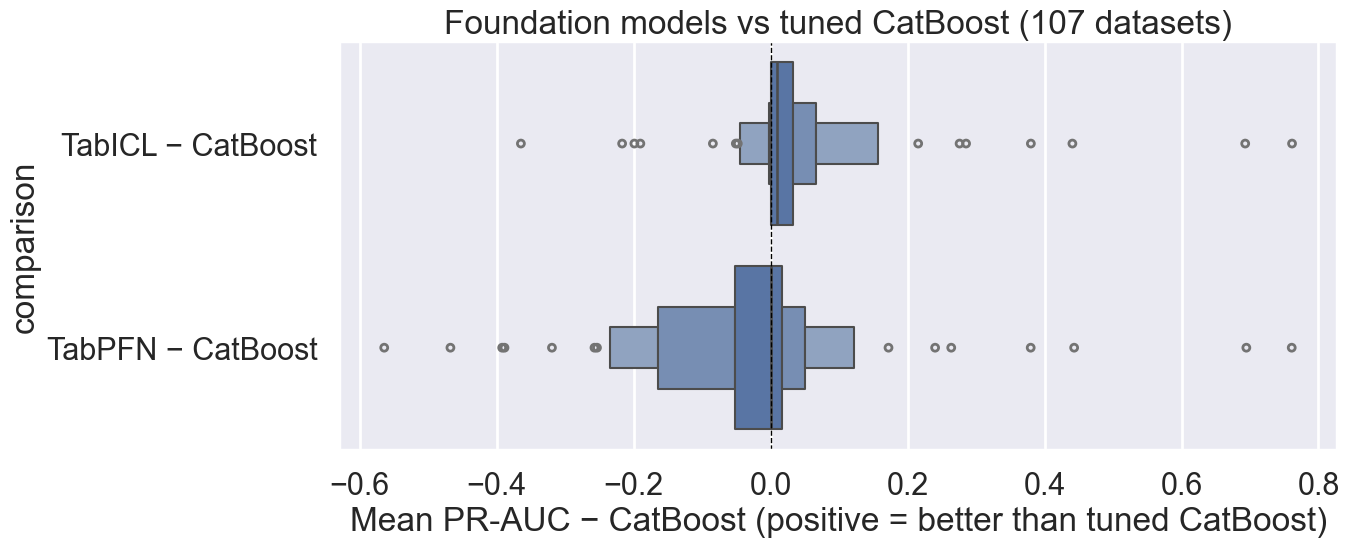

In [5]:
# Per-dataset delta vs CatBoost (baseline for this comparison)
cb = pivot['CatBoost']
delta_df = pd.DataFrame({
    'TabICL − CatBoost': pivot['TabICL'] - cb,
    'TabPFN − CatBoost': pivot['TabPFN'] - cb,
}).reset_index().melt(id_vars='dataset', var_name='comparison', value_name='delta')

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxenplot(data=delta_df, x='delta', y='comparison', ax=ax)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Mean PR-AUC − CatBoost (positive = better than tuned CatBoost)')
ax.set_title(f'Foundation models vs tuned CatBoost ({len(active)} datasets)')
plt.tight_layout()
plt.savefig('results/tabicl_vs_others_delta_boxen.png', dpi=120)
plt.show()

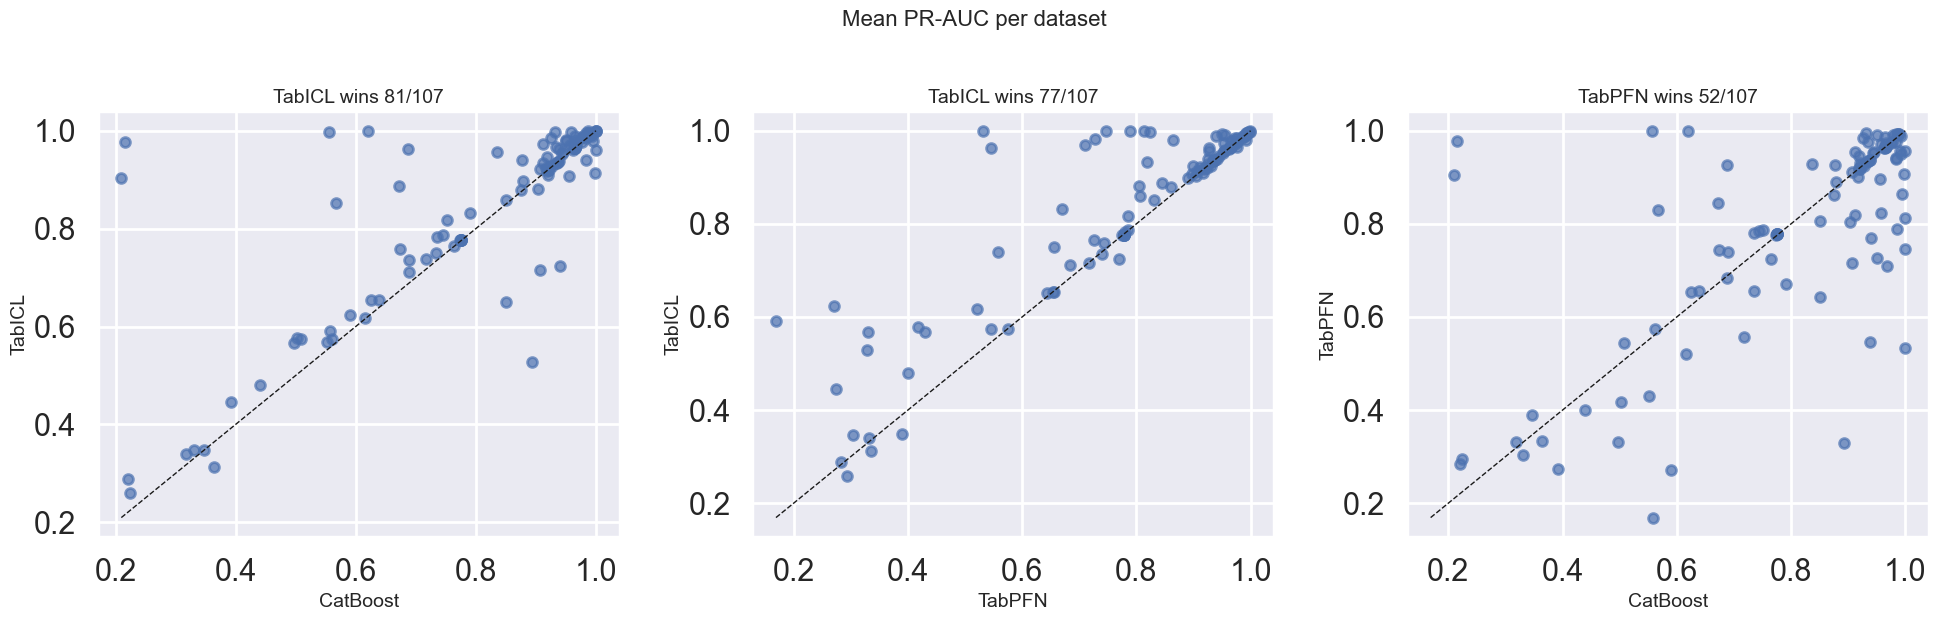

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
pairs = [
    ('TabICL', 'CatBoost'),
    ('TabICL', 'TabPFN'),
    ('TabPFN', 'CatBoost'),
]
for ax, (a, b) in zip(axes, pairs):
    sub = pivot[[a, b]].dropna()
    ax.scatter(sub[b], sub[a], alpha=0.7, s=50)
    lims = [min(sub.min()), max(sub.max())]
    ax.plot(lims, lims, 'k--', linewidth=1)
    ax.set_xlabel(b, fontsize=14)
    ax.set_ylabel(a, fontsize=14)
    n_win = (sub[a] > sub[b]).sum()
    ax.set_title(f'{a} wins {n_win}/{len(sub)}', fontsize=14)
fig.suptitle('Mean PR-AUC per dataset', fontsize=16)
plt.tight_layout()
plt.savefig('results/tabicl_vs_others_scatter.png', dpi=120)
plt.show()

In [7]:
rank = pivot.rank(axis=1, ascending=False, method='average')
rank_counts = pd.DataFrame(index=labels)
for r in range(1, len(labels) + 1):
    rank_counts[f'rank_{r}'] = (rank == r).sum()
rank_counts['mean_rank'] = rank.mean()
print('Rank distribution (lower mean_rank = better):')
print(rank_counts.sort_values('mean_rank').to_string())

Rank distribution (lower mean_rank = better):
          rank_1  rank_2  rank_3  mean_rank
TabICL        62      32      11   1.514019
TabPFN        21      40      46   2.233645
CatBoost      22      33      50   2.252336


In [8]:
# Time per dataset comparison
time_pivot = df.pivot_table(index='dataset', columns='model', values='time')
ratio = pd.DataFrame({
    'TabICL / CatBoost': time_pivot['TabICL'] / time_pivot['CatBoost'],
    'TabPFN / CatBoost': time_pivot['TabPFN'] / time_pivot['CatBoost'],
    'TabICL / TabPFN':   time_pivot['TabICL'] / time_pivot['TabPFN'],
})
print('Time ratio (X / Y means X is N× slower than Y):')
print(ratio.agg(['median', 'mean']).round(2).to_string())

Time ratio (X / Y means X is N× slower than Y):
        TabICL / CatBoost  TabPFN / CatBoost  TabICL / TabPFN
median               1.29               9.64             0.24
mean                 3.97              23.05             0.28


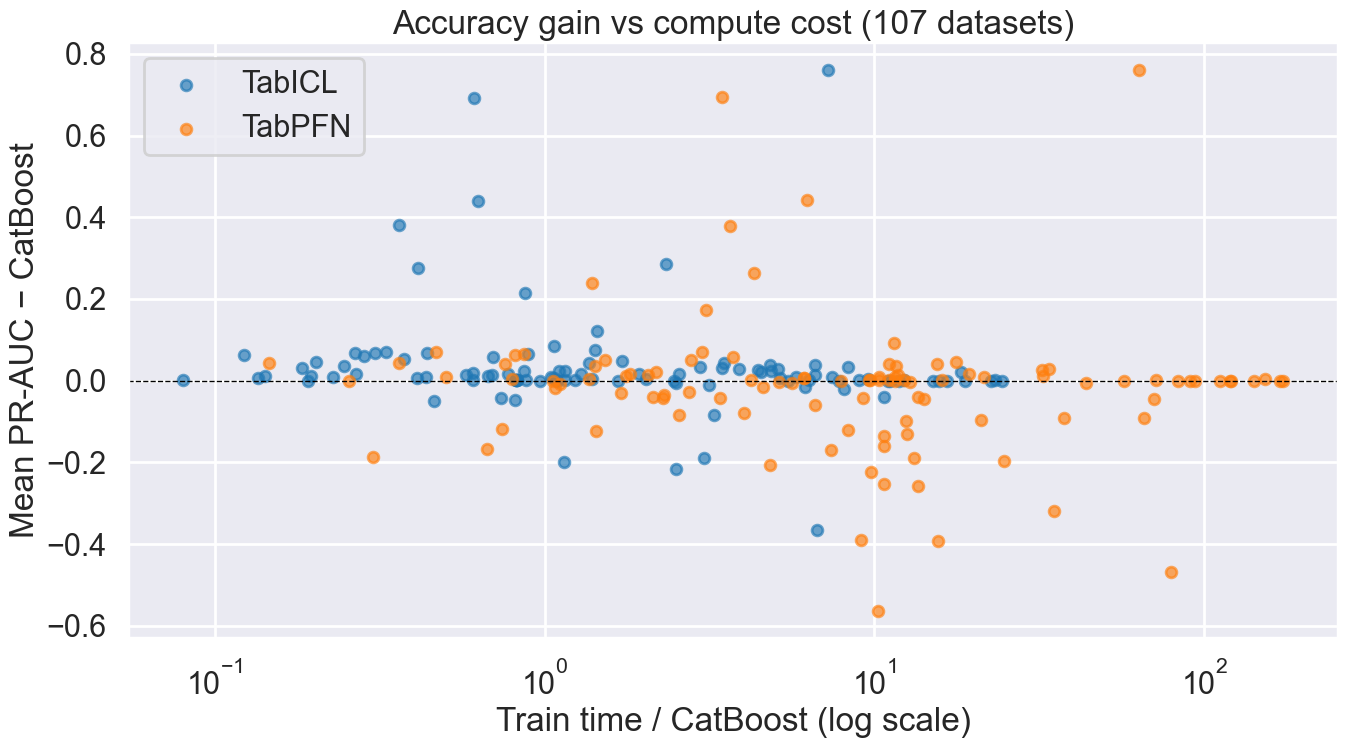

In [9]:
# Worth it? PR-AUC gain over CatBoost vs time cost
fig, ax = plt.subplots(figsize=(14, 8))
for name, color in [('TabICL', 'tab:blue'), ('TabPFN', 'tab:orange')]:
    delta = (pivot[name] - cb)
    t_ratio = (time_pivot[name] / time_pivot['CatBoost'])
    valid = (~delta.isna()) & (~t_ratio.isna())
    ax.scatter(t_ratio[valid], delta[valid], alpha=0.65, s=60, color=color, label=name)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xscale('log')
ax.set_xlabel('Train time / CatBoost (log scale)')
ax.set_ylabel('Mean PR-AUC − CatBoost')
ax.set_title(f'Accuracy gain vs compute cost ({len(active)} datasets)')
ax.legend()
plt.tight_layout()
plt.savefig('results/tabicl_vs_others_cost_vs_gain.png', dpi=120)
plt.show()

In [10]:
delta_vs_cb = pd.DataFrame({
    'TabICL': pivot['TabICL'] - cb,
    'TabPFN': pivot['TabPFN'] - cb,
    'CatBoost': cb,
}).dropna()
print('Top 10 datasets where TabICL beats CatBoost most:')
print(delta_vs_cb.sort_values('TabICL', ascending=False).head(10).to_string())
print()
print('Top 10 datasets where CatBoost beats TabICL most:')
print(delta_vs_cb.sort_values('TabICL').head(10).to_string())

Top 10 datasets where TabICL beats CatBoost most:
                                 TabICL    TabPFN  CatBoost
dataset                                                    
seismic-bumps                  0.761425  0.760963  0.216055
thoracic-surgery               0.693033  0.694683  0.209633
hill-valley-with-noise         0.440654  0.443213  0.556032
hill-valley-without-noise      0.380000  0.379751  0.619862
autoUniv-au1-1000              0.285366  0.263708  0.566968
hepatitis                      0.275886  0.240165  0.687164
blogger                        0.215429  0.172089  0.672642
statlog-vehicle-silhouettes    0.121171  0.091718  0.836055
teaching-assistant-evaluation  0.084400  0.070517  0.673535
indian-liver-patient           0.075713 -0.084471  0.501778

Top 10 datasets where CatBoost beats TabICL most:
                             TabICL    TabPFN  CatBoost
dataset                                                
blood-transfusion-service -0.364774 -0.564383  0.893211
appendiciti

In [ ]:
# Are TabICL and TabPFN blind on the same datasets?
icl_d = pivot['TabICL'] - cb
pfn_d = pivot['TabPFN'] - cb
joint = pd.concat([icl_d.rename('TabICL'), pfn_d.rename('TabPFN')], axis=1).dropna()
corr = joint.corr().iloc[0, 1]
both_win  = ((joint['TabICL'] >= 0.01) & (joint['TabPFN'] >= 0.01)).sum()
both_lose = ((joint['TabICL'] <= -0.01) & (joint['TabPFN'] <= -0.01)).sum()
disagree  = ((np.sign(joint['TabICL']) != np.sign(joint['TabPFN'])) &
              (joint.abs() >= 0.01).any(axis=1)).sum()
print(f'corr(TabICL-CatBoost, TabPFN-CatBoost) over {len(joint)} datasets: {corr:.3f}')
print(f'both foundation models beat CatBoost (Δ ≥ +0.01): {both_win}')
print(f'both foundation models lose to CatBoost (Δ ≤ −0.01): {both_lose}')
print(f'disagree (sign-flip with |Δ| ≥ 0.01 somewhere): {disagree}')

fig, ax = plt.subplots(figsize=(9, 9))
ax.scatter(joint['TabPFN'], joint['TabICL'], alpha=0.65, s=50)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
lim = max(joint.abs().max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], 'k:', linewidth=1, alpha=0.5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel('TabPFN − CatBoost')
ax.set_ylabel('TabICL − CatBoost')
ax.set_title(f'Foundation models share blind spots (corr={corr:.2f})')
plt.tight_layout()
plt.savefig('results/tabicl_vs_others_foundation_corr.png', dpi=120)
plt.show()

In [ ]:
# Does TabICL's advantage over CatBoost depend on dataset size?
nrow = df.drop_duplicates('dataset').set_index('dataset')['nrow']
size_df = pd.DataFrame({
    'nrow':  nrow,
    'delta': pivot['TabICL'] - cb,
}).dropna()
bins = [0, 200, 500, 1000, 3000, 10000]
size_df['bucket'] = pd.cut(size_df['nrow'], bins=bins, include_lowest=True)
agg = size_df.groupby('bucket', observed=True)['delta'].agg(['count', 'mean', 'median'])
agg['win_rate'] = size_df.groupby('bucket', observed=True)['delta'].apply(lambda x: (x > 0).mean())
print('TabICL − CatBoost delta by dataset size:')
print(agg.round(4).to_string())

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxenplot(data=size_df, x='bucket', y='delta', ax=ax)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Number of training samples (bucketed)')
ax.set_ylabel('TabICL − CatBoost')
ax.set_title(f'TabICL advantage vs dataset size ({len(size_df)} datasets)')
plt.tight_layout()
plt.savefig('results/tabicl_vs_catboost_by_size.png', dpi=120)
plt.show()

## Conclusions

On 107 shared non-trivial datasets:

### Headline

**TabICL is the new default** for this kind of small tabular data. It wins 76% of head-to-head comparisons with tuned CatBoost (mean Δ +0.033 PR-AUC), 72% against TabPFN (mean Δ +0.050), and lands rank-1 on 62/107 datasets vs ~22 each for TabPFN and CatBoost. Its mean rank (1.51) is half a rank ahead of the others (~2.24).

### Cost is no longer the blocker

- TabICL **median train time is 190s** — only **1.3× slower than CatBoost** (143s), and **4× FASTER than TabPFN** (724s).
- This makes TabICL the rare foundation model that's competitive on both accuracy AND wall-clock for everyday use.
- TabPFN is now strictly dominated: TabICL is both more accurate (78/108 wins) and faster.
- Mean ratios are higher (TabICL/CatBoost ≈ 4×, TabPFN/CatBoost ≈ 23×) — large datasets pull foundation-model time up, but the median is what matters for typical use.

### Where TabICL shines

Big wins are concentrated where gradient boosters underfit due to noise or sparse signal:
- `seismic-bumps` +0.76, `thoracic-surgery` +0.69 — heavy class imbalance, CatBoost lands near random-chance PR-AUC, TabICL prior knowledge wins
- `hill-valley-with/without-noise` +0.38–0.44 — synthetic data with structured noise GB cannot regularize away
- `hepatitis` +0.28, `blogger` +0.22, `autoUniv-au1-1000` +0.29 — small-data noise pattern

### Shared blind spots

TabICL and TabPFN fail on the **same** datasets (correlation of deltas vs CatBoost is high). These are the foundation-model failure mode:
- `blood-transfusion-service` (TabICL −0.36, TabPFN −0.56), `appendicitis`, `saheart`, `pima-indians-diabetes` — small medical datasets with severe class imbalance where CatBoost's regularization + class weighting dominates pre-trained priors
- `thyroid-sick-euthyroid`, `wilt` — extreme imbalance (positives rare), CatBoost gets ~0.998 PR-AUC, TabICL ~0.91

Practical implication: foundation models are not a free win on every dataset. For severely imbalanced binary classification, tuned GB is still the safe choice.

### Practical recommendation

For small tabular classification on this kind of data:

1. **Default to TabICL.** Zero HP tuning, ~3 min median train time, beats 50-trial-Optuna CatBoost on ~3/4 of datasets.
2. **Always co-train CatBoost.** It's the only model that wins meaningfully on the blind-spot datasets (severe class imbalance + small n), and it's cheap.
3. **Drop TabPFN.** TabICL strictly dominates it on accuracy and speed.

See [TabPFN_notes.md](TabPFN_notes.md) for the older foundation model's limits and [FT_transformer_notes.md](FT_transformer_notes.md) for why FT-Transformer (the heavy CPU foundation model attempt) was abandoned.